# Leapfrog integration paths on the Rosenbrock distribution

This notebook reproduces the classic "leapfrog trajectories" figure (curved dotted
integration paths joining the accepted samples shown as red dots), rendered in the
*usual* Rosenbrock style (the `magma` log-density background).

We compare three samplers:

* the **Riemannian** sampler (`ImplicitRHMCSampler` with the Rosenbrock SoftAbs metric) — baseline,
* the **Finsler / Unbiased** sampler **without** flip reduction (`reduced_flip=False`),
* the **Finsler / Unbiased** sampler **with** flip reduction (`reduced_flip=True`).

The target is the Rosenbrock distribution
$$\pi(x,y)\propto\exp\!\big(-[100(y-x^2)^2+(1-x)^2]/20\big).$$

**Same number of samples for every method.** Each sampler is run until exactly
`N_ACCEPT` proposals have been *accepted*, so all three panels show the same number
of red dots and dotted leapfrog paths regardless of their (very different)
acceptance rates.

**Rejection.** A proposal is accepted with the usual Metropolis rate, *and
additionally rejected if its leapfrog trajectory ever leaves the distribution* —
i.e. if any point along the path drops below a target log-density floor `LEVEL` (the
same level used as the `magma` display floor). This removes the off-density
outliers: trajectories that wander into the near-zero-density (black) region are
rejected by the accept/reject step and never drawn.


In [82]:
import torch
from torch import Tensor
from torch.linalg import LinAlgError

import numpy as np
import matplotlib.pyplot as plt

from geodesic_toolbox.cometric import RosenbrockSoftAbs, RosenbrockDualRanders
from geodesic_toolbox.samplers import ImplicitRHMCSampler, ImplicitFHMCUnbiased

## Target density and sampler definitions

Both samplers share the same Rosenbrock potential `U`. `log_pi` is the (unnormalised)
target log-density; the Finsler sampler additionally uses the dual Randers cometric,
and the two Finsler variants differ only through the `reduced_flip` flag.

In [83]:
def log_pi(z: Tensor) -> Tensor:
    """Unnormalised Rosenbrock log-density, log pi(x, y)."""
    x, y = z[..., 0], z[..., 1]
    return -(100 * (y - x**2) ** 2 + (1 - x) ** 2) / 20


def U_rosenbrock(z: Tensor) -> Tensor:
    return -log_pi(z)


class RosenbrockRHMC(ImplicitRHMCSampler):
    """Riemannian HMC on the Rosenbrock distribution (SoftAbs metric)."""

    def __init__(self, l, N_fx, gamma, N_run, alpha=1.0, **kwargs):
        super().__init__(RosenbrockSoftAbs(alpha), l, N_fx, gamma, N_run, **kwargs)

    def U(self, z):
        return U_rosenbrock(z)


class RosenbrockFHMCUnbiased(ImplicitFHMCUnbiased):
    """Finsler (Unbiased) HMC on the Rosenbrock distribution.

    The flip-reduction behaviour is controlled by ``reduced_flip``.
    """

    def __init__(self, l, N_fx, gamma, N_run, alpha=1.0, beta=1.0, **kwargs):
        randers = RosenbrockDualRanders(alpha=alpha, beta=beta)
        super().__init__(randers_cometric=randers, l=l, N_fx=N_fx,
                         gamma=gamma, N_run=N_run, **kwargs)

    def U(self, z):
        return U_rosenbrock(z)


## Recording the leapfrog paths until `n_accept` acceptances

We re-run the sampling loop by hand and keep going **until `n_accept` proposals have
been accepted** (or `max_iter` iterations elapse, as a safety cap). Only accepted
moves grow the chain and contribute a dotted leapfrog path, so every method yields
exactly `n_accept` paths and `1 + n_accept` red dots (the start plus the accepted
states).

`on_manifold` flags whether an *entire* leapfrog trajectory stays on the
distribution (`log_pi >= LEVEL` everywhere); proposals leaving the density have their
acceptance probability forced to zero.

There are two loops: the standard one (Riemannian) and the unbiased one, which
carries a per-chain integration direction `dirs`, flips it on rejection, and — when
`reduced_flip=True` — uses the reduced momentum-flip rule (Sohl-Dickstein 2012).

In [84]:
def on_manifold(traj_q: Tensor, level: float) -> Tensor:
    """True for each chain whose whole leapfrog trajectory keeps log_pi >= level."""
    return (log_pi(traj_q) >= level).all(dim=1)


def record_paths_standard(sampler, z0, n_accept, level, seed=0, max_iter=20000):
    """RHMC loop run until `n_accept` accepted proposals (density-based rejection)."""
    torch.manual_seed(seed)
    z = z0.clone()
    chain = [z[0].clone()]
    paths = []
    accepted = it = 0
    while accepted < n_accept and it < max_iter:
        it += 1
        v0 = sampler.sample_momentum(z)
        try:
            traj_q, traj_p = sampler.leapfrog(z, v0, return_traj=True)
            alpha = sampler.get_alpha(z, v0, traj_q[:, -1], traj_p[:, -1])
            alpha = torch.where(on_manifold(traj_q, level), alpha, torch.zeros_like(alpha))
        except LinAlgError:
            alpha = torch.zeros(z.shape[0])
            traj_q = None
        u = torch.rand_like(alpha)
        if (alpha[0] >= u[0]).item() and traj_q is not None:
            paths.append(traj_q[0].detach().clone())
            z = traj_q[:, -1].clone()
            chain.append(z[0].clone())
            accepted += 1
    return torch.stack(chain), paths, accepted / it, it


def record_paths_unbiased(sampler, z0, n_accept, level, seed=0, max_iter=20000):
    """Unbiased Finsler loop run until `n_accept` accepted proposals.

    Mirrors ``ImplicitFHMCUnbiased.sample`` (including the ``reduced_flip`` rule read
    from ``sampler.reduced_flip``). The integration direction ``dirs`` flips on every
    rejection, whether or not the move is accepted.
    """
    torch.manual_seed(seed)
    z = z0.clone()
    dirs = torch.ones(z.shape[0], device=z.device)
    chain = [z[0].clone()]
    paths = []
    accepted = flipped = it = 0

    def region_alpha(z_, v_, dirs_):
        traj_q, traj_p = sampler.leapfrog(z_, v_, dirs_, return_traj=True)
        a = sampler.get_alpha(z_, v_, traj_q[:, -1], traj_p[:, -1])
        a = torch.where(on_manifold(traj_q, level), a, torch.zeros_like(a))
        return a, traj_q

    while accepted < n_accept and it < max_iter:
        it += 1
        v0 = sampler.sample_momentum(z)
        try:
            alpha, traj_q = region_alpha(z, v0, dirs)
        except LinAlgError:
            alpha = torch.zeros(z.shape[0])
            traj_q = None

        u = torch.rand_like(alpha)
        accept = u < alpha

        if sampler.reduced_flip:
            alpha_flip = torch.zeros_like(alpha)
            rej = (~accept).nonzero(as_tuple=False).squeeze(-1)
            if rej.numel() > 0:
                try:
                    af, _ = region_alpha(z[rej], v0[rej], -dirs[rej])
                except LinAlgError:
                    af = torch.zeros(rej.numel())
                alpha_flip[rej] = af
            p_flip = (alpha_flip - alpha).clamp(min=0)
            flip = (~accept) & (u < alpha + p_flip)
        else:
            flip = ~accept

        if accept[0].item() and traj_q is not None:
            paths.append(traj_q[0].detach().clone())
            z = traj_q[:, -1].clone()
            chain.append(z[0].clone())
            accepted += 1
        dirs = torch.where(flip, -dirs, dirs)
        flipped += flip.sum().item()
    return torch.stack(chain), paths, accepted / it, flipped / it, it


## Plotting helper and density floor

`LEVEL` is the target log-density floor used both as the `magma` display floor
(`vmin`) and for the rejection above, so "on the manifold" means exactly "visible on
the plotted density".

In [85]:
GRID = 400
XG = np.linspace(-6, 6, GRID)
YG = np.linspace(-1, 25, GRID)
_grid = torch.tensor(np.stack(np.meshgrid(XG, YG), axis=-1), dtype=torch.float32)
LOG_PI = log_pi(_grid).numpy()
VMAX = np.percentile(LOG_PI, 99)
LEVEL = np.percentile(LOG_PI, 92)        # density floor: display vmin AND rejection threshold
EXTENT = [XG.min(), XG.max(), YG.min(), YG.max()]
print(f"LEVEL (log_pi floor) = {LEVEL:.2f}")


def plot_leapfrog_paths(ax, chain, paths, title=None):
    ax.imshow(LOG_PI, origin="lower", extent=EXTENT, cmap="magma",
              aspect="auto", vmin=LEVEL, vmax=VMAX, zorder=0)
    for path in paths:
        p = path.numpy()
        ax.plot(p[:, 0], p[:, 1], linestyle=(0, (1, 1)), linewidth=1.0,
                color="black", alpha=0.9, zorder=2)
    c = chain.numpy()
    ax.scatter(c[:, 0], c[:, 1], s=28, facecolor="red",
               edgecolor="black", linewidth=0.4, zorder=3)
    ax.set_xlim(XG.min(), XG.max())
    ax.set_ylim(YG.min(), YG.max())
    ax.set_xlabel("$x$")
    ax.set_ylabel("$y$")
    if title:
        ax.set_title(title)


LEVEL (log_pi floor) = -8.46


## Shared parameters

`N_ACCEPT` fixes the number of accepted samples (hence dots/paths) per method.
`N_run` only feeds the momentum-tempering schedule (inactive here since `beta_0=1`),
so it can be a nominal value.

In [86]:
l = 10
N_fx = 6
gamma = 0.57
beta = 0.4          # Randers drift strength (Finsler samplers)
seed = 42

N_ACCEPT = 20       # wait for this many acceptances in every method
MAX_ITER = 20000    # safety cap on iterations
N_run = MAX_ITER    # nominal (tempering schedule only)

z0 = torch.tensor([[0.4, 0.5]])


## Riemannian sampler (baseline)

RHMC  accepted=20 in 23 iters (acc=0.870)


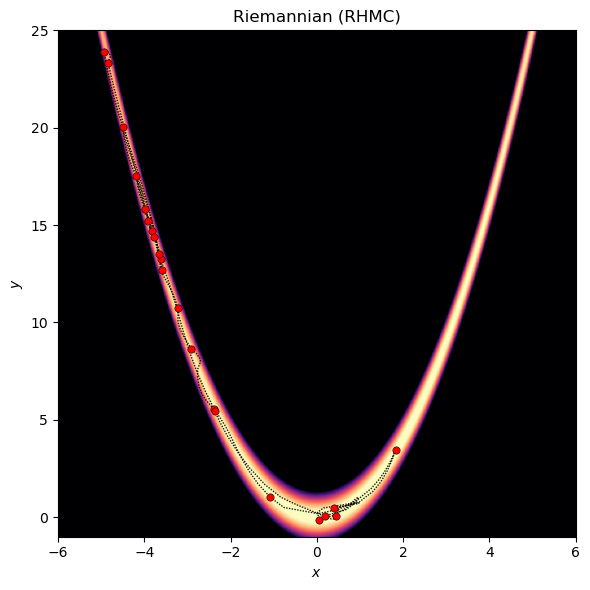

In [87]:
rhmc = RosenbrockRHMC(l, N_fx, gamma, N_run)
chain_r, paths_r, acc_r, it_r = record_paths_standard(rhmc, z0, N_ACCEPT, LEVEL, seed=seed, max_iter=MAX_ITER)
print(f"RHMC  accepted={len(paths_r)} in {it_r} iters (acc={acc_r:.3f})")

fig, ax = plt.subplots(figsize=(6, 6))
plot_leapfrog_paths(ax, chain_r, paths_r, title="Riemannian (RHMC)")
plt.tight_layout()
plt.show()


## Finsler / Unbiased — without flip reduction

Unbiased (no flip reduction)  accepted=20 in 95 iters (acc=0.211, flip=0.789)


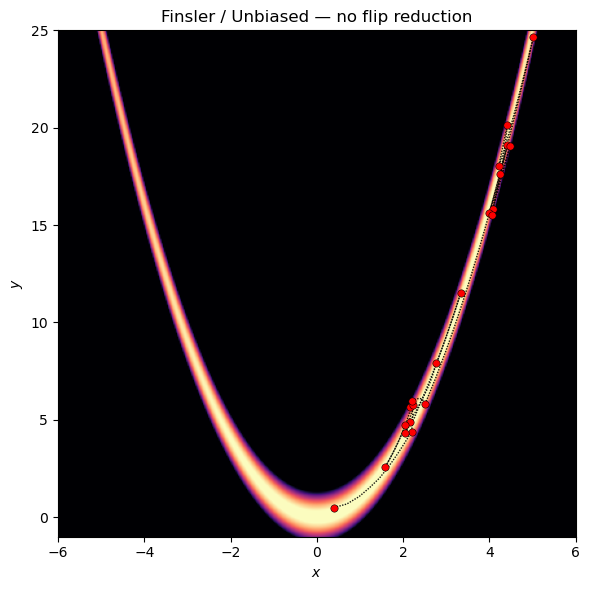

In [88]:
unbiased_noflip = RosenbrockFHMCUnbiased(l, N_fx, gamma, N_run, beta=beta, reduced_flip=False)
chain_nf, paths_nf, acc_nf, flip_nf, it_nf = record_paths_unbiased(
    unbiased_noflip, z0, N_ACCEPT, LEVEL, seed=seed, max_iter=MAX_ITER)
print(f"Unbiased (no flip reduction)  accepted={len(paths_nf)} in {it_nf} iters "
      f"(acc={acc_nf:.3f}, flip={flip_nf:.3f})")

fig, ax = plt.subplots(figsize=(6, 6))
plot_leapfrog_paths(ax, chain_nf, paths_nf, title="Finsler / Unbiased — no flip reduction")
plt.tight_layout()
plt.show()


## Finsler / Unbiased — with flip reduction

Unbiased (reduced flip)       accepted=20 in 95 iters (acc=0.211, flip=0.147)


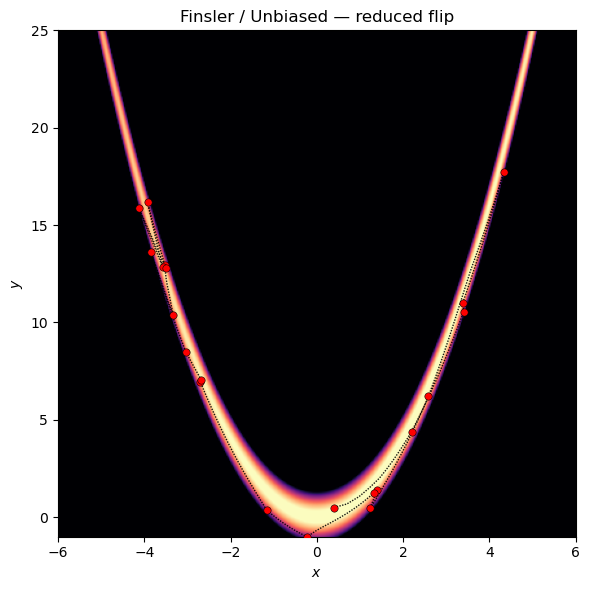

In [89]:
unbiased_flip = RosenbrockFHMCUnbiased(l, N_fx, gamma, N_run, beta=beta, reduced_flip=True)
chain_rf, paths_rf, acc_rf, flip_rf, it_rf = record_paths_unbiased(
    unbiased_flip, z0, N_ACCEPT, LEVEL, seed=seed, max_iter=MAX_ITER)
print(f"Unbiased (reduced flip)       accepted={len(paths_rf)} in {it_rf} iters "
      f"(acc={acc_rf:.3f}, flip={flip_rf:.3f})")

fig, ax = plt.subplots(figsize=(6, 6))
plot_leapfrog_paths(ax, chain_rf, paths_rf, title="Finsler / Unbiased — reduced flip")
plt.tight_layout()
plt.show()


## Combined figure

All three methods show the same `N_ACCEPT` accepted samples. Proposals whose leapfrog
trajectory leaves the density (any point below `LEVEL`) are rejected, so every dotted
path and red dot stays on the distribution.

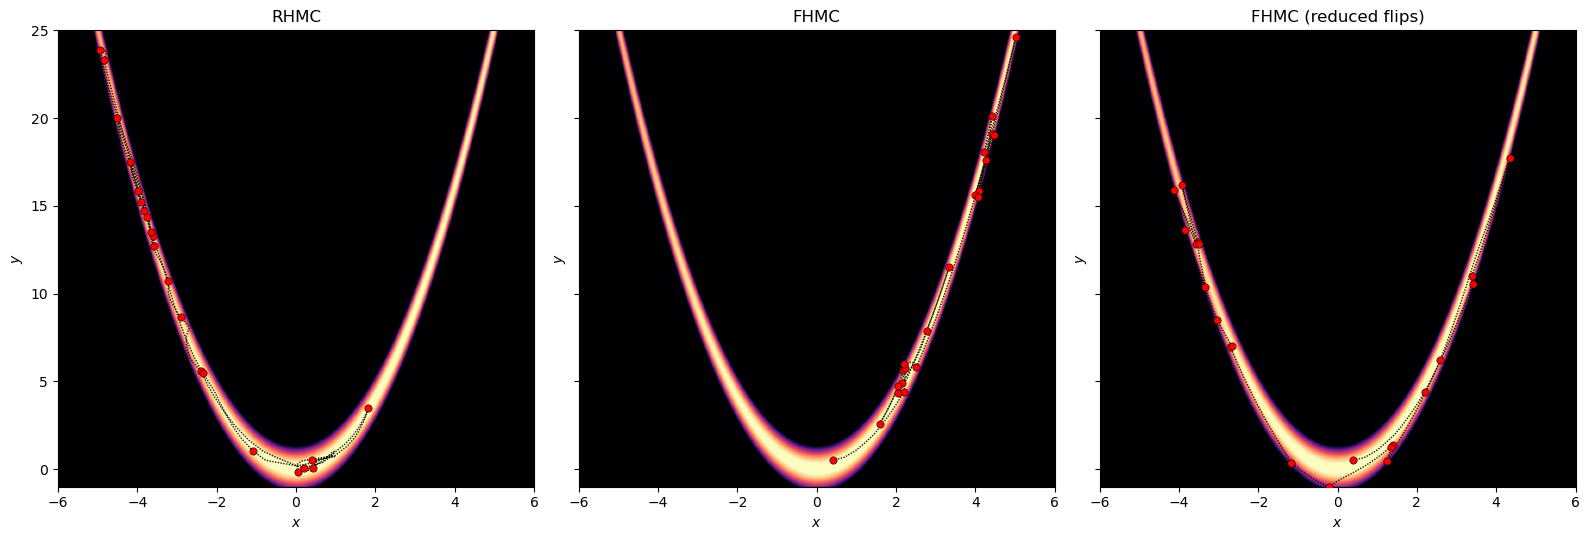

In [91]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), sharex=True, sharey=True)
plot_leapfrog_paths(axes[0], chain_r, paths_r, title="RHMC")
plot_leapfrog_paths(axes[1], chain_nf, paths_nf, title="FHMC")
plot_leapfrog_paths(axes[2], chain_rf, paths_rf, title="FHMC (reduced flips)")
plt.tight_layout()
plt.show()
